In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import sklearn
import sys
import pathlib
sys.path.append(str(pathlib.Path.cwd().parent.parent))
import ISRUtilities as isru
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _periEventGLM(session,regs=None,when=None,delay=[0],limits=(-0.1,0.1),shuffle=1):
    # predict peri-event spikes with region spike matrices just before (1 time bin)

    # load data
    R = fma.regions.regions(session,events='InfraSlowRhythm/infraslowaval',phases=when)
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    events, is_coupled = isru.loadHpcPfcEvents(session,coupl=True)

    # y: PFC post-ripple activity MAKE CUSTOMIZABLE
    pfc_spikes = R.spikes(regs='pfc')
    delta_pfc = fma.analysis.PETH(pfc_spikes[:,0],events['ripples'],groups=pfc_spikes[:,1],limits=(0.2,0.3),n_bins=1,fast=True)[0].squeeze() # (events, units)
    delta_pfc = delta_pfc[:,np.sum(delta_pfc!=0,axis=0)>2] # remove units with no spikes

    rng = np.random.default_rng()
    scores = []
    scores_sh = []
    for d in delay:
        # X : preceding spikes
        spikes = R.spikes(regs=regs)
        peth, t, _ = fma.analysis.PETH(spikes[:,0],events['ripples']+d,groups=spikes[:,1],limits=limits,n_bins=1,fast=True) # (events, time, units)
        X = peth.reshape(len(peth),-1).squeeze() # (events, units)

        # train per neuron
        scores.append([])
        scores_sh.append([])
        print(f'{delta_pfc.shape[1]} units:')
        for i in range(delta_pfc.shape[1]):
            print(f'{i} ',end='')

            # 1. observed
            y = delta_pfc[:,i]
            model = sklearn.linear_model.PoissonRegressor(alpha=1.0,max_iter=5000)
            scores[-1].append(np.median(sklearn.model_selection.cross_val_score(model,X,y)))

            # 2. surrogate
            scores_sh[-1].append([])
            for k in range(shuffle):
                rng.shuffle(y)
                model = sklearn.linear_model.PoissonRegressor(alpha=1.0,max_iter=5000)
                scores_sh[-1][-1].append(np.median(sklearn.model_selection.cross_val_score(model,X,y)))
        print()

    return scores, scores_sh

In [3]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][12]
print(session)
regs = ['hpc','nr','pfc']
keys = ['hpc','nr','pfc']
delay = np.linspace(-0.4,0,20)
scores = {}
scores_sh = {}
for i, r in enumerate(regs):
    scores[keys[i]], scores_sh[keys[i]] = _periEventGLM(session,regs=r,delay=delay,shuffle=10)

/mnt/hubel-data-139/perceval/Rat003_20231228/Rat003_20231228.xml
74 units:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 

/home/pietro/uvEnvs/fmat_edit_12/lib/python3.12/site-packages/sklearn/_loss/link.py:165: RuntimeWarning: divide by zero encountered in log
  return xp.log(y_pred)


36 37 38 39 40 41 42 

/home/pietro/uvEnvs/fmat_edit_12/lib/python3.12/site-packages/sklearn/_loss/link.py:165: RuntimeWarning: divide by zero encountered in log
  return xp.log(y_pred)


43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 

...

43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 

/home/pietro/uvEnvs/fmat_edit_12/lib/python3.12/site-packages/sklearn/_loss/link.py:165: RuntimeWarning: divide by zero encountered in log
  return xp.log(y_pred)


68 69 70 71 72 73 

/home/pietro/uvEnvs/fmat_edit_12/lib/python3.12/site-packages/sklearn/_loss/link.py:165: RuntimeWarning: divide by zero encountered in log
  return xp.log(y_pred)



74 units:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 
74 units:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 
74 units:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 
74 units:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 
74 units:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35

/home/pietro/uvEnvs/fmat_edit_12/lib/python3.12/site-packages/scipy/_lib/_util.py:307: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


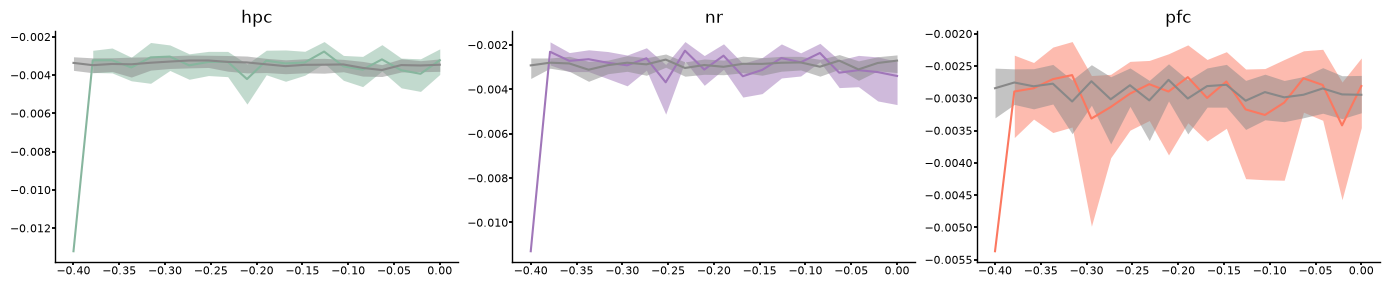

In [5]:
# see scores
fig, ax = fma.plotting.makeFigure(size=(35,7),n=(1,len(scores)))
for i, k in enumerate(keys):
    fma.plotting.semPlot(delay,np.array(scores[k]).T,color=isru.paperColors(k),ax=ax[i])
    fma.plotting.semPlot(delay,np.array(scores_sh[k]).mean(axis=-1).T,color=isru.paperColors('shuffle'),ax=ax[i])
    ax[i].set(title=keys[i])